In [14]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict,Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [15]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(model="gemini-1.5-flash",google_api_key=GEMINI_API_KEY)

In [16]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description="The sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

structured_model1 = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [11]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    result: str

graph = StateGraph(ReviewState) 


In [17]:
def find_Sentiment(State: ReviewState):
    prompt = f'Classify the sentiment of the following review as positive or negative : {State["review"]}'

    State['sentiment'] = structured_model.invoke(prompt).sentiment

    return {'sentiment': State['sentiment']}

def check_condition(State: ReviewState)->Literal['positive_response','run_diagnosis']:
    if State['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(State: ReviewState):

    prompt = f'write a warm thank you msg in response to the {State["review"]}'
    result = model.invoke(prompt).content
    return {'result': State['result']}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    result = structured_model2.invoke(prompt)

    return {'diagnosis': result.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    result = model.invoke(prompt).content

    return {'result': result}

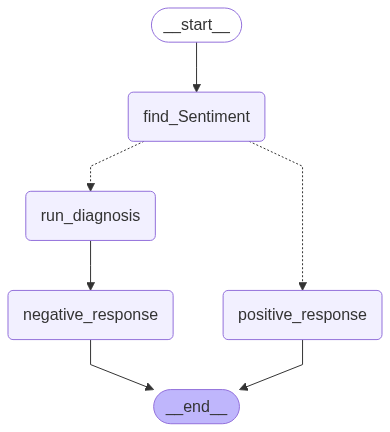

In [12]:
graph.add_node('find_Sentiment',find_Sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)

graph.add_edge(START,'find_Sentiment')
graph.add_conditional_edges('find_Sentiment',check_condition)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow = graph.compile()
workflow

In [ ]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'result': 'Subject: Re: Urgent - Bug Report - [Original Subject Line]\n\nHi [User Name],\n\nI\'m so sorry to hear you\'re experiencing this issue and understand your frustration.  A high-urgency bug is definitely not something anyone wants to deal with.  Thanks for reporting it so promptly and providing [mention specific details they gave, e.g.,  "the detailed steps to reproduce the problem"]. This is really helpful in helping us resolve this quickly.\n\nI\'ve escalated this to our development team immediately. They\'re working on identifying the root cause and implementing a fix.  We\'ll keep you updated on the progress.  In the meantime, [O